# Experiment 11: Convolutional Neural Networks (CNNs) & The Effect of Padding

**Objective**: Build a simple Convolutional Neural Network (CNN) for image classification and understand the impact of `padding='valid'` (no padding) versus `padding='same'` (zero-padding) on feature map dimensions and model performance.

**Dataset**: MNIST (Handwritten Digits)

**Methodology**:
1. Load and preprocess the MNIST dataset (keeping the 2D spatial structure this time).
2. Build Model A: A simple CNN with **no padding** (`padding='valid'`).
3. Build Model B: A simple CNN with **zero-padding** (`padding='same'`).
4. Compare the model summaries to observe how the spatial dimensions of the feature maps change.
5. Train both models and compare their final performance.

## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


## 2. Load and Preprocess Dataset

Unlike MLPs (which required flattening the image to 1D vectors), CNNs expect to retain the spatial 2D grid structure.

In [2]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values to be between 0 and 1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Expand dimensions to add the "channel" dimension required by CNNs (Num_Images, Height, Width, Channels)
# MNIST only has 1 channel (Grayscale)
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)

# One-hot encode the labels
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


## 3. Compare Padding Strategies

When a convolutional filter (e.g., $3 \times 3$) slides over an image, it cannot center itself on the edge pixels without hanging off the edge of the image.

1. **`padding='valid'` (Default, No Padding)**: The filter only slides over valid positions within the image. This causes the output feature map to shrink in height and width.
   - Formula: $W_{out} = W_{in} - F + 1$ (for Stride=1, $F$ = Filter Size)
2. **`padding='same'` (Zero Padding)**: The image is padded with zeros around the border so the filter can safely process edge pixels. This ensures the output feature map has the **exact same** height and width as the input.
   - Formula: $W_{out} = W_{in}$ (for Stride=1)

### Model A: Simple CNN (Valid Padding / Shrinking)

In [3]:
def build_model_valid():
    model = keras.Sequential([
        keras.Input(shape=(28, 28, 1)),
        
        # Conv Layer 1 (3x3 filter, valid padding)
        layers.Conv2D(32, kernel_size=(3, 3), padding="valid", activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        # Conv Layer 2 (3x3 filter, valid padding)
        layers.Conv2D(64, kernel_size=(3, 3), padding="valid", activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        # Classification Head
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(10, activation="softmax")
    ], name="Model_A_Valid_Padding")
    
    model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
    return model

model_valid = build_model_valid()
print("Model A Summary (Notice the Output Shapes shrinking below 28x28 before pooling):")
model_valid.summary()

Model A Summary (Notice the Output Shapes shrinking below 28x28 before pooling):


Model: "Model_A_Valid_Padding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

### Model B: Simple CNN (Same Padding / Preservation)

In [4]:
def build_model_same():
    model = keras.Sequential([
        keras.Input(shape=(28, 28, 1)),
        
        # Conv Layer 1 (3x3 filter, same padding)
        layers.Conv2D(32, kernel_size=(3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        # Conv Layer 2 (3x3 filter, same padding)
        layers.Conv2D(64, kernel_size=(3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        # Classification Head
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(10, activation="softmax")
    ], name="Model_B_Same_Padding")
    
    model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
    return model

model_same = build_model_same()
print("\nModel B Summary (Notice the Output Shapes remain at their original spatial size before pooling):")
model_same.summary()


Model B Summary (Notice the Output Shapes remain at their original spatial size before pooling):


Model: "Model_B_Same_Padding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        31,370 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,186 (196.04 KB)

 Trainable params: 50,186 (196.04 KB)

 Non-trainable params: 0 (0.00 B)

**Observation from Summaries:**
- In **Model A (`valid`)**: The first 28x28 image passes through a $3 \times 3$ Conv2D layer resulting in a **$26 \times 26$** image. The pixels on the absolute border were lost.
- In **Model B (`same`)**: The first 28x28 image passes through a $3 \times 3$ Conv2D layer resulting in a **$28 \times 28$** image because identical zeros were padded around the borders to allow the filter to scan the edges directly.
- The resulting `Flatten()` layer is significantly larger in Model B (3136 elements) vs Model A (1600 elements) because we retained more spatial information across all feature maps.

## 4. Train and Compare Both Models

In [5]:
epochs = 5
batch_size = 128

print("Training Model A (Valid Padding)...")
history_valid = model_valid.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1, verbose=1)

print("\nTraining Model B (Same Padding)...")
history_same = model_same.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1, verbose=1)

Training Model A (Valid Padding)...
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 95ms/step - accuracy: 0.8941 - loss: 0.3496 - val_accuracy: 0.9785 - val_loss: 0.0764
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 95ms/step - accuracy: 0.9673 - loss: 0.1065 - val_accuracy: 0.9843 - val_loss: 0.0537
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 95ms/step - accuracy: 0.9746 - loss: 0.0810 - val_accuracy: 0.9882 - val_loss: 0.0425
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9795 - loss: 0.0671 - val_accuracy: 0.9885 - val_loss: 0.0398
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 95ms/step - accuracy: 0.9812 - loss: 0.0601 - val_accuracy: 0.9898 - val_loss: 0.0360

Training Model B (Same Padding)...
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 59s 137ms/step - accuracy: 0.8960 - loss: 0.3409 - val_accuracy: 0.9808 - val_loss: 0.0745
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 58s 136ms/step - accuracy: 0.9685 - loss: 0.1013 - val_accuracy: 0.9863 - val_loss: 0.0554
Epoch 3/5
422/422 ━━━━━

## 5. Evaluate and Visualize Results

In [6]:
score_valid = model_valid.evaluate(X_test, y_test, verbose=0)
score_same = model_same.evaluate(X_test, y_test, verbose=0)

print("Model A (Valid Padding) Test Accuracy:", score_valid[1])
print("Model B (Same Padding)  Test Accuracy:", score_same[1])

Model A (Valid Padding) Test Accuracy: 0.9887999892234802
Model B (Same Padding)  Test Accuracy: 0.9878000020980835


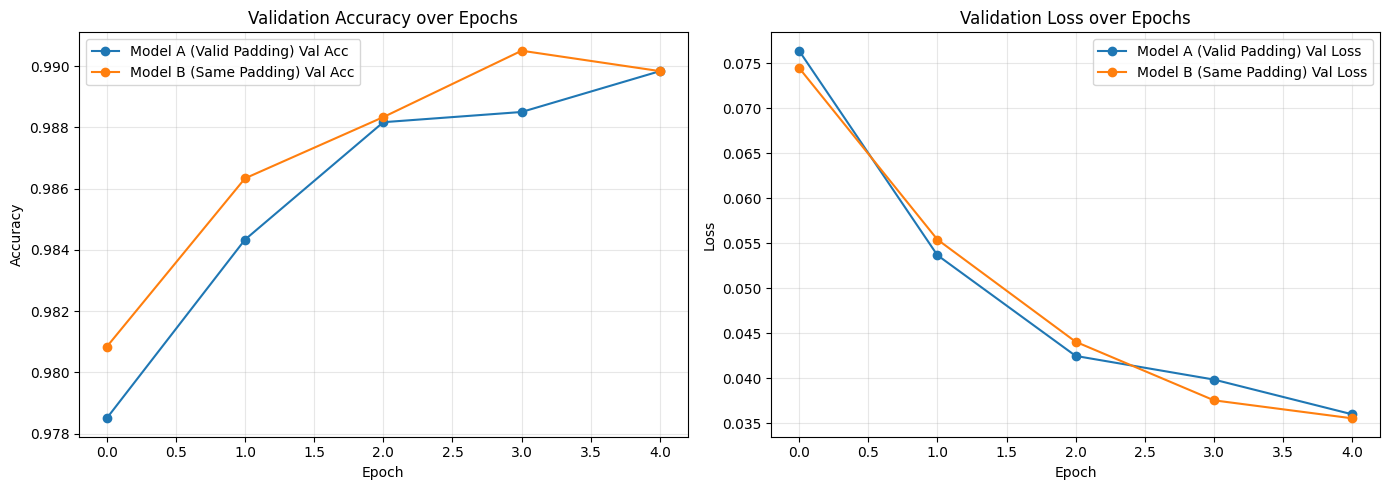

In [7]:
plt.figure(figsize=(14, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history_valid.history['val_accuracy'], label='Model A (Valid Padding) Val Acc', marker='o')
plt.plot(history_same.history['val_accuracy'], label='Model B (Same Padding) Val Acc', marker='o')
plt.title('Validation Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history_valid.history['val_loss'], label='Model A (Valid Padding) Val Loss', marker='o')
plt.plot(history_same.history['val_loss'], label='Model B (Same Padding) Val Loss', marker='o')
plt.title('Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Conclusion / Observations

1. **Architectural Differences (Spatial Dimensions)**: If you check the network summary, the first Max Pooling layer receives a `26x26` input for the Valid padding model, but a `28x28` input for the Same padding model.
2. **Information Retention**: `padding='same'` preserves the edge pixel patterns. This is frequently preferred in Computer Vision workflows (like ResNet architecture) specifically because maintaining standard dimensional milestones lets models go deeper without prematurely "crushing" the pixel coordinate fields down to 1x1 grids before extracting meaningful semantic features.
3. **Performance Difference**: Padding primarily impacts deep or complex architectures rather than highly simplified digit identifiers. Both networks should easily score >98% accuracy on MNIST; however, `padding='same'` might exhibit marginally faster initial convergence or slight final gains.